In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv("data.csv")
df.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,survival_3yr
0,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1.0,0.0,0.0,1
1,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,1.0,0.0,0.0,0
2,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,10.4678,0.000,10.3002,0.002,9.8687,0.001,1.0,0.0,0.0,1
3,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1.0,0.0,0.0,1
4,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1.0,0.0,0.0,1


In [24]:
from imblearn.over_sampling import RandomOverSampler
X = df.drop('survival_3yr', axis=1)
y = df['survival_3yr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [25]:
def find_threshold_for_min_recall(y_true, y_proba, min_recall=0.70):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision = np.append(precision, 1.0)
    recall = np.append(recall, 0.0)
    thresholds = np.append(thresholds, 1.0)
    valid = recall >= min_recall
    if not np.any(valid):
        return None, None, None, None
    best_idx = np.argmax(precision * valid)
    p, r, t = precision[best_idx], recall[best_idx], thresholds[best_idx]
    f1 = f1_score_from_pr(p, r)
    return t, p, r, f1

def f1_score_from_pr(p, r):
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)


In [26]:
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model_configs = {
    "Regresión Logística": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
        "params": {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__solver": ['liblinear', 'saga']}
    },
    "SVM": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", SVC(class_weight='balanced', probability=True, random_state=42))]),
        "params": {"clf__C": [0.1, 1, 10], "clf__gamma": ['scale', 'auto', 0.001, 0.01], "clf__kernel": ['rbf', 'linear']}
    },
    "KNN": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "params": {"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ['uniform', 'distance'], "clf__metric": ['euclidean', 'manhattan']}
    },
    "Random Forest": {
        "pipeline": Pipeline([("clf", RandomForestClassifier(class_weight='balanced', random_state=42))]),
        "params": {"clf__n_estimators": [50, 100, 200], "clf__max_depth": [3, 5, 7, None], "clf__min_samples_split": [2, 5, 10]}
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([("clf", GradientBoostingClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__max_depth": [3, 5, 7],
            "clf__subsample": [0.8, 1.0]
        }
    },
    "AdaBoost": {
        "pipeline": Pipeline([("clf", AdaBoostClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0]
        }
    },
    "Extra Trees": {
        "pipeline": Pipeline([("clf", ExtraTreesClassifier(class_weight='balanced', random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 5, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([("clf", XGBClassifier(
            scale_pos_weight=pos_weight,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [27]:
results = []
min_recall_required = 0.70
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"🔍 Optimizando {len(model_configs)} modelos con búsqueda aleatoria (20 iteraciones c/u)...")
print(f"🎯 Requiere recall ≥ {min_recall_required:.0%} en clase positiva ('Fallece <3 años')\n")

for name, config in model_configs.items():
    print(f"🔹 {name}")
    
    search = RandomizedSearchCV(
        config["pipeline"],
        config["params"],
        n_iter=20,
        cv=cv,
        scoring='average_precision',  # mejor que AUC-ROC en clases desbalanceadas
        n_jobs=-1,
        random_state=42
    )
    
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print(f"   ❌ Error durante entrenamiento: {e}\n")
        continue
    
    best_model = search.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    thresh, prec, rec, f1 = find_threshold_for_min_recall(y_test, y_proba, min_recall=min_recall_required)
    
    if thresh is None:
        print(f"   ❌ No alcanza recall ≥ {min_recall_required:.0%}\n")
        continue
    
    y_pred = (y_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    results.append({
        "Modelo": name,
        "Umbral": thresh,
        "Recall": rec,
        "Precisión": prec,
        "F1-score": f1,
        "VPN": vpn,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "best_params": search.best_params_
    })
    
    print(f"   ✅ Recall: {rec:.1%} | Precisión: {prec:.1%} | F1: {f1:.3f} | Umbral: {thresh:.3f}")
    print(f"   📊 AUC-PR: {auc_pr:.3f} | VPN: {vpn:.1%}\n")


🔍 Optimizando 8 modelos con búsqueda aleatoria (20 iteraciones c/u)...
🎯 Requiere recall ≥ 70% en clase positiva ('Fallece <3 años')

🔹 Regresión Logística
   ✅ Recall: 83.9% | Precisión: 41.9% | F1: 0.559 | Umbral: 0.416
   📊 AUC-PR: 0.388 | VPN: 85.3%

🔹 SVM
   ✅ Recall: 74.2% | Precisión: 36.5% | F1: 0.489 | Umbral: 0.179
   📊 AUC-PR: 0.329 | VPN: 75.8%

🔹 KNN
   ✅ Recall: 77.4% | Precisión: 36.9% | F1: 0.500 | Umbral: 0.404
   📊 AUC-PR: 0.302 | VPN: 77.4%

🔹 Random Forest
   ✅ Recall: 96.8% | Precisión: 37.5% | F1: 0.541 | Umbral: 0.225
   📊 AUC-PR: 0.366 | VPN: 93.8%

🔹 Gradient Boosting
   ✅ Recall: 77.4% | Precisión: 36.4% | F1: 0.495 | Umbral: 0.039
   📊 AUC-PR: 0.353 | VPN: 76.7%

🔹 AdaBoost
   ✅ Recall: 74.2% | Precisión: 35.4% | F1: 0.479 | Umbral: 0.468
   📊 AUC-PR: 0.303 | VPN: 74.2%

🔹 Extra Trees
   ✅ Recall: 93.5% | Precisión: 39.7% | F1: 0.558 | Umbral: 0.251
   📊 AUC-PR: 0.330 | VPN: 91.3%

🔹 XGBoost
   ✅ Recall: 87.1% | Precisión: 34.6% | F1: 0.495 | Umbral: 0.033
  


🏆 === RESUMEN FINAL (ordenado por F1-score) ===
             Modelo  Umbral  Recall  Precisión  F1-score   VPN  AUC-ROC  AUC-PR
Regresión Logística   0.416   0.839      0.419     0.559 0.853    0.623   0.388
        Extra Trees   0.251   0.935      0.397     0.558 0.913    0.543   0.330
      Random Forest   0.225   0.968      0.375     0.541 0.938    0.538   0.366
                KNN   0.404   0.774      0.369     0.500 0.774    0.486   0.302
            XGBoost   0.033   0.871      0.346     0.495 0.778    0.485   0.336
  Gradient Boosting   0.039   0.774      0.364     0.495 0.767    0.529   0.353
                SVM   0.179   0.742      0.365     0.489 0.758    0.530   0.329
           AdaBoost   0.468   0.742      0.354     0.479 0.742    0.475   0.303


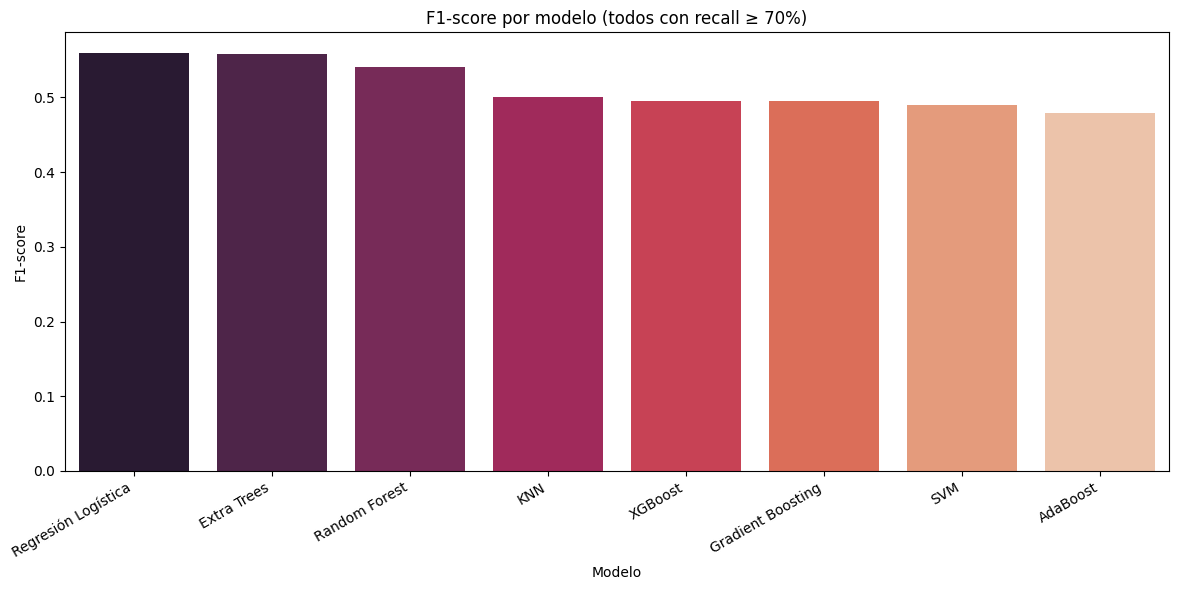

In [28]:
if results:
    summary = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_proba', 'best_params']} for r in results])
    summary_sorted = summary.sort_values('F1-score', ascending=False)
    
    print("\n🏆 === RESUMEN FINAL (ordenado por F1-score) ===")
    print(summary_sorted.to_string(index=False, float_format='%.3f'))
    
    # Guardar
    summary_sorted.to_csv("resultados_comparacion_modelos_recall70.csv", index=False)
    
    # Gráfico
    plt.figure(figsize=(12, 6))
    sns.barplot(data=summary_sorted, x='Modelo', y='F1-score', palette='rocket')
    plt.title('F1-score por modelo (todos con recall ≥ 70%)')
    plt.ylabel('F1-score')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig("f1_score_modelos.png", dpi=200)
    plt.show()
    
    # Opcional: guardar hiperparámetros
    params_summary = pd.DataFrame([{"Modelo": r["Modelo"], "Mejores Hiperparámetros": r["best_params"]} for r in results])
    params_summary.to_json("mejores_hiperparametros.json", indent=2)
    
else:
    print("❌ Ningún modelo cumplió con el recall mínimo requerido.")

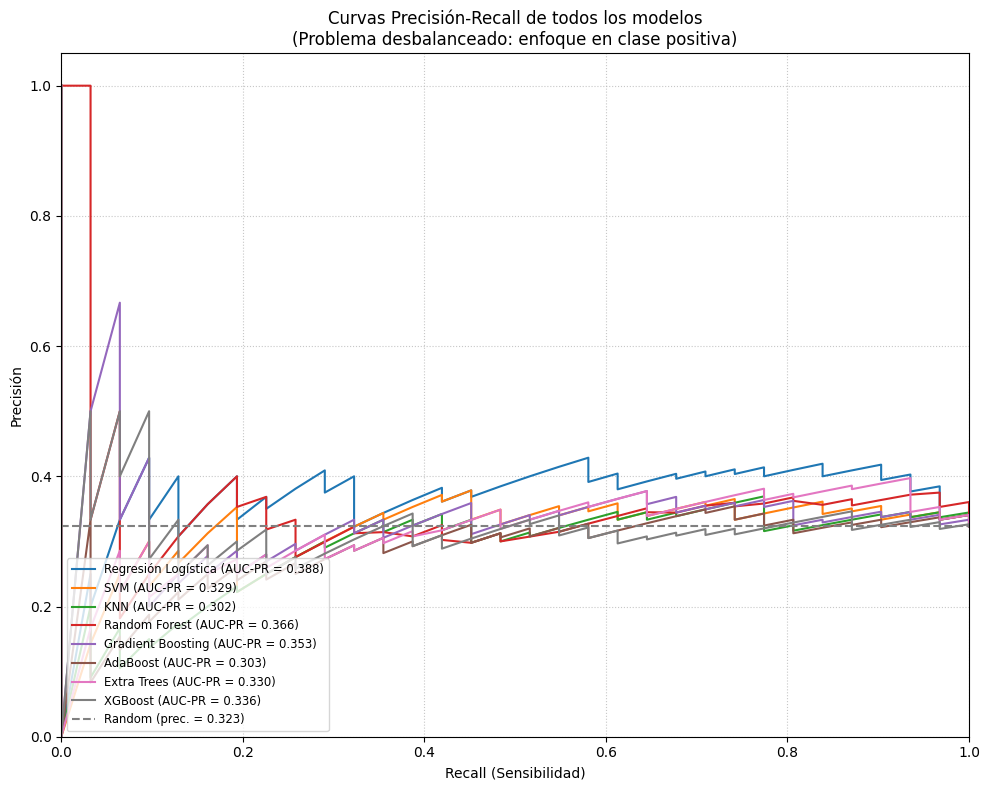

In [29]:
plt.figure(figsize=(10, 8))

for r in results:
    name = r["Modelo"]
    y_proba = r["y_proba"]
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    
    plt.plot(recall, precision, label=f'{name} (AUC-PR = {auc_pr:.3f})')

# Línea horizontal: precisión de una predicción aleatoria (baseline)
baseline_precision = np.mean(y_test)  # proporción de positivos en el conjunto de prueba
plt.axhline(y=baseline_precision, color='gray', linestyle='--', label=f'Random (prec. = {baseline_precision:.3f})')

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curvas Precisión-Recall de todos los modelos\n(Problema desbalanceado: enfoque en clase positiva)')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig("curvas_precision_recall_todos_modelos.png", dpi=200)
plt.show()

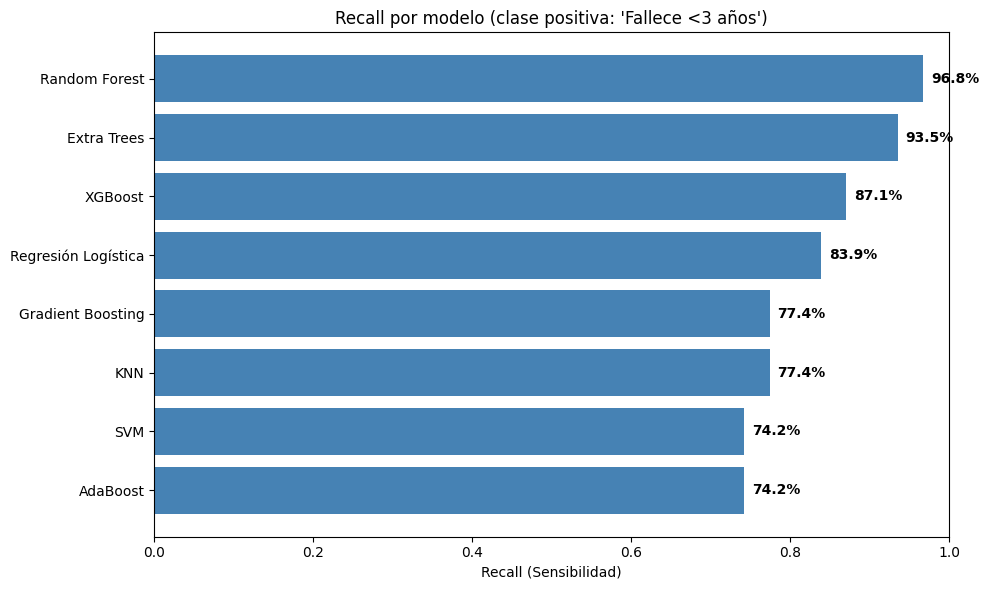

In [30]:
model_names = [r["Modelo"] for r in results]
recall_scores = [r["Recall"] for r in results]

# Crear DataFrame y ordenar por recall (descendente)
recall_df = pd.DataFrame({"Modelo": model_names, "Recall": recall_scores})
recall_df = recall_df.sort_values("Recall", ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
bars = plt.barh(recall_df["Modelo"], recall_df["Recall"], color="steelblue")
plt.xlabel("Recall (Sensibilidad)")
plt.title("Recall por modelo (clase positiva: 'Fallece <3 años')")
plt.xlim(0, 1)
plt.gca().invert_yaxis()  # Mejor legibilidad: mejor modelo arriba

# Añadir valores en las barras
for i, v in enumerate(recall_df["Recall"]):
    plt.text(v + 0.01, i, f"{v:.1%}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("recall_por_modelo.png", dpi=200)
plt.show()